# Feature Engineering and Modeling

Here we will play around with feature engineering and our models `XGBoost_ROS` and `RF_SMOTE` from [baseline_modeling.ipynb](baseline_modeling.ipynb). For convenience here is a python snippet of their 'uncalibrated versions':

```python


baselines_smote['RF_SMOTE'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


baselines_ROS['XGBoost_ROS'] = ImbPipeline([
    ('preprocessor', preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])

```

## 1. Imports

In [1]:
## Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import notebook_file_utilities.auto_add_project_root as proroot
import pathlib
import shap
import sklearn


# Models

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold

# imbalance learning
from imblearn.over_sampling import SMOTE,RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline


from xgboost import XGBClassifier


# sklearn preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, 
                                    FunctionTransformer, 
                                    StandardScaler)


# Calibration
from sklearn.calibration import CalibratedClassifierCV


# For reading in modules from src and reading/saving files
project_root = proroot.auto_add_project_root()

import src.modeling.model_summary as mds
import src.modeling.train_test_split as tts
import src.modeling.analysis_utilities as au
import src.pipeline.transformers as tf


sklearn.set_config(transform_output="default")



## 2. Train-Validation Split

We read in our training and validation data created in [baseline_modeling.ipynb](baseline_modeling.ipynb)

In [2]:
train_data=pd.read_csv(project_root/pathlib.Path('data/train_val_test_splits/train_data.csv'))
val_data = pd.read_csv(project_root/pathlib.Path('data/train_val_test_splits/val_data.csv'))
train_data['DATE'] = pd.to_datetime(train_data['DATE'])
val_data['DATE'] = pd.to_datetime(val_data['DATE'])
y_train = train_data['TORNADO_OCCURRENCE']
X_train = train_data.drop(columns = ['TORNADO_OCCURRENCE'])

y_val = val_data['TORNADO_OCCURRENCE']
X_val = val_data.drop(columns = ['TORNADO_OCCURRENCE'])

expanding_cv=tts.YearlyTemporalWindowSplit(start_year=2001, end_year=2017,val_window_size=2)

tts.print_cv_split_check(expanding_cv, train_data, date_column='DATE',target_column='TORNADO_OCCURRENCE')

CROSS-VALIDATION SPLIT VERIFICATION

Total number of folds: 8
Dataset size: 509,364 samples
Overall tornado rate: 0.1480%

--------------------------------------------------------------------------------

Fold 1:
  Train: 2000-01-01 to 2000-12-31
         26,196 samples, 18 tornadoes (0.0687%)
  Val:   2001-01-01 to 2002-12-31
         52,094 samples, 44 tornadoes (0.0845%)

Fold 2:
  Train: 2000-01-01 to 2002-12-31
         78,290 samples, 62 tornadoes (0.0792%)
  Val:   2003-01-01 to 2004-12-31
         54,579 samples, 117 tornadoes (0.2144%)

Fold 3:
  Train: 2000-01-01 to 2004-12-31
         132,869 samples, 179 tornadoes (0.1347%)
  Val:   2005-01-01 to 2006-12-31
         63,561 samples, 31 tornadoes (0.0488%)

Fold 4:
  Train: 2000-01-01 to 2006-12-31
         196,430 samples, 210 tornadoes (0.1069%)
  Val:   2007-01-01 to 2008-12-31
         58,069 samples, 126 tornadoes (0.2170%)

Fold 5:
  Train: 2000-01-01 to 2008-12-31
         254,499 samples, 336 tornadoes (0.1320%)
  Val

,fold,train_size,val_size,train_rate,val_rate,train_tornadoes,val_tornadoes
0,1,26196,52094,0.000687,0.000845,18,44
1,2,78290,54579,0.000792,0.002144,62,117
2,3,132869,63561,0.001347,0.000488,179,31
3,4,196430,58069,0.001069,0.002170,210,126
4,5,254499,62950,0.001320,0.001700,336,107
5,6,317449,60929,0.001395,0.001789,443,109
6,7,378378,51294,0.001459,0.001618,552,83
7,8,429672,51044,0.001478,0.001842,635,94


## 3. Feature Engineering 

Feature engineering will be achieved through scikit-learn compatible transformers from the module [transformers](../src/pipeline/transformers.py) (read in as tf).

|Transformer|Parameters|Description|Importance|
|-----------|------------|----------|---------|
|tf.HourlyRates| `columns`,`min_gap_hours`,`max_gap_hours`| Calculate hourly rate of change for meteorological variables.|Unstable conditions are good indicators for tornadic potential.  |
|tf.DewTempSpread| `new_col`| Creates a new column (named new_col) whose values are from taking the difference between air temperature and dew point| Small values in TMP-DEW indicate high moisture content, a key ingredient for thunderstorms.|
|tf.DatetimeSinCosConverter|`monthofyear`, `dayofyear`, `hourofday`| Given a datatime column creates new columns with cyclic sine,cosine representations of months in year 1--12, days in year 1--365, hours in day 0--23.|Captures temporal patterns from datetime columns|

---

### 3.1 Feature Engineering Checks 

We apply our feature engineering transformations to `X_val` to check that nothing unexpected occurs:

In [3]:

tf.HourlyRates(columns=['DEW_dew_point','TMP_air_temperature','SLP_sea_level_pressure'], min_gap_hours=1, max_gap_hours=2).fit_transform(X_val).describe()




,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_speed_rate,CIG_ceiling_height,VIS_distance,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure,PER_HOUR_DEW_dew_point,PER_HOUR_TMP_air_temperature,PER_HOUR_SLP_sea_level_pressure
count,5.366900e+04,53669.000000,53669.000000,53669.000000,53669,53232.000000,53669.000000,53669.000000,53669.000000,53669.000000,53669.000000,53669.000000,46758.000000,46758.000000,46758.000000
mean,7.235381e+10,35.444622,-97.536269,393.484572,2018-12-24 06:10:18.497829376,172.784791,50.203954,14263.569286,14971.338314,153.267976,88.212245,10163.725913,0.077290,0.097047,-0.054592
min,7.235301e+10,35.388900,-97.646940,391.700000,2017-12-31 23:52:00,0.000000,0.000000,0.000000,0.000000,-156.000000,-206.000000,9898.000000,-205.000000,-139.000000,-50.000000
25%,7.235301e+10,35.388900,-97.646940,391.700000,2018-06-24 18:26:00,110.000000,31.000000,1524.000000,16093.000000,67.000000,0.000000,10115.000000,-5.000000,-6.000000,-4.000000
50%,7.235401e+10,35.416670,-97.600600,393.500000,2018-12-23 02:52:00,170.000000,46.000000,22000.000000,16093.000000,161.000000,100.000000,10153.000000,0.000000,0.000000,0.000000
75%,7.235440e+10,35.534170,-97.383330,395.300000,2019-06-21 01:52:00,210.000000,67.000000,22000.000000,16093.000000,240.000000,190.000000,10208.000000,5.000000,6.000000,4.000000
max,7.235440e+10,35.534170,-97.383330,395.300000,2019-12-31 23:52:00,360.000000,206.000000,22000.000000,16093.000000,444.000000,256.000000,10475.000000,116.000000,122.000000,69.000000
std,5.748317e+05,0.061685,0.116948,1.436443,NaN,102.162780,27.538818,9862.682918,3340.973184,108.129816,105.790044,73.915035,8.708776,13.400608,6.587410


In [4]:
tf.DewTempSpread('TMP-DEW').transform(X_val)

,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_type_code,WND_speed_rate,CIG_ceiling_height,CIG_cavok_code,VIS_distance,VIS_variability_code,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure,WND_direction_angle_variable_wind_direction_flag,TMP-DEW
0,72354013919,35.41667,-97.38333,393.5,2018-01-01 05:56:00,20.0,N,62.0,22000.0,N,16093.0,N,-117.0,-192.0,10440.0,False,75.0
1,72354013919,35.41667,-97.38333,393.5,2018-01-01 06:56:00,360.0,N,46.0,22000.0,N,16093.0,N,-125.0,-187.0,10440.0,False,62.0
2,72354013919,35.41667,-97.38333,393.5,2018-01-01 07:56:00,30.0,N,62.0,22000.0,N,16093.0,N,-129.0,-195.0,10448.0,False,66.0
3,72354013919,35.41667,-97.38333,393.5,2018-01-01 08:56:00,10.0,N,57.0,22000.0,N,16093.0,N,-135.0,-191.0,10447.0,False,56.0
4,72354013919,35.41667,-97.38333,393.5,2018-01-01 09:56:00,20.0,N,57.0,22000.0,N,16093.0,N,-139.0,-193.0,10452.0,False,54.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53664,72353013967,35.38890,-97.60060,391.7,2019-12-31 19:52:00,260.0,N,26.0,22000.0,N,16093.0,N,100.0,-111.0,10211.0,False,211.0
53665,72353013967,35.38890,-97.60060,391.7,2019-12-31 20:52:00,270.0,N,36.0,22000.0,N,16093.0,N,106.0,-100.0,10203.0,False,206.0
53666,72353013967,35.38890,-97.60060,391.7,2019-12-31 21:52:00,240.0,N,46.0,22000.0,N,16093.0,N,100.0,-72.0,10199.0,False,172.0
53667,72353013967,35.38890,-97.60060,391.7,2019-12-31 22:52:00,230.0,N,31.0,22000.0,N,16093.0,N,89.0,-78.0,10195.0,False,167.0


In [5]:
tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True).transform(X_val).describe()

,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_speed_rate,CIG_ceiling_height,VIS_distance,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure,sin_monthofyear,cos_monthofyear,sin_dayofyear,cos_dayofyear,sin_hourofday,cos_hourofday
count,5.366900e+04,53669.000000,53669.000000,53669.000000,53669,53232.000000,53669.000000,53669.000000,53669.000000,53669.000000,53669.000000,53669.000000,5.366900e+04,5.366900e+04,53669.000000,53669.000000,53669.000000,5.366900e+04
mean,7.235381e+10,35.444622,-97.536269,393.484572,2018-12-24 06:10:18.497829376,172.784791,50.203954,14263.569286,14971.338314,153.267976,88.212245,10163.725913,1.781074e-02,1.217843e-02,0.017945,0.019329,-0.002324,-1.801351e-02
min,7.235301e+10,35.388900,-97.646940,391.700000,2017-12-31 23:52:00,0.000000,0.000000,0.000000,0.000000,-156.000000,-206.000000,9898.000000,-1.000000e+00,-1.000000e+00,-0.999991,-0.999963,-1.000000,-1.000000e+00
25%,7.235301e+10,35.388900,-97.646940,391.700000,2018-06-24 18:26:00,110.000000,31.000000,1524.000000,16093.000000,67.000000,0.000000,10115.000000,-8.660254e-01,-5.000000e-01,-0.705584,-0.671260,-0.707107,-7.071068e-01
50%,7.235401e+10,35.416670,-97.600600,393.500000,2018-12-23 02:52:00,170.000000,46.000000,22000.000000,16093.000000,161.000000,100.000000,10153.000000,1.224647e-16,6.123234e-17,0.025818,0.038722,0.000000,-1.836970e-16
75%,7.235440e+10,35.534170,-97.383330,395.300000,2019-06-21 01:52:00,210.000000,67.000000,22000.000000,16093.000000,240.000000,190.000000,10208.000000,8.660254e-01,5.000000e-01,0.741222,0.714673,0.707107,7.071068e-01
max,7.235440e+10,35.534170,-97.383330,395.300000,2019-12-31 23:52:00,360.000000,206.000000,22000.000000,16093.000000,444.000000,256.000000,10475.000000,1.000000e+00,1.000000e+00,0.999991,1.000000,1.000000,1.000000e+00
std,5.748317e+05,0.061685,0.116948,1.436443,NaN,102.162780,27.538818,9862.682918,3340.973184,108.129816,105.790044,73.915035,7.145510e-01,6.992639e-01,0.714635,0.699014,0.708285,7.057060e-01


### 3.2 Feature Engineering and Preprocessing Implementation


Our preprocessing strategy uses scikit-learn's `ColumnTransformer` to handle different feature types appropriately. We define multiple preprocessing configurations to systematically evaluate the impact of different engineered features on model performance

We note that the transformations making up our preprocessor in the [baseline_modeling](baseline_modeling.ipynb) notebook show up here too. For convenience here is a brief snippet of this original preprocessor:

```python
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ]
)
```

#### 3.2.1 Feature Categories

Features are organized into the following categories based on their type and whether they are original features :

| Category | Features | Description |
|----------|----------|-------------|
| **Temporal (Engineered)** | `sin_monthofyear`, `cos_monthofyear`, `sin_hourofday`, `cos_hourofday` | Cyclic encodings of time components |
| **Meteorological (Engineered)** | `TMP-DEW` | Temperature-dewpoint spread |
| **Rate of Change (Engineered)** | `PER_HOUR_DEW_dew_point`, `PER_HOUR_TMP_air_temperature`, `PER_HOUR_SLP_sea_level_pressure` | Hourly rates of change for key atmospheric variables |
| **Numeric (Original)** | `WND_direction_angle`, `WND_speed_rate`, `CIG_ceiling_height`, `VIS_distance`, `TMP_air_temperature`, `DEW_dew_point`, `SLP_sea_level_pressure` | Raw weather measurements |
| **Binary Coded** | `CIG_cavok_code`, `VIS_variability_code` | Categorical binary indicators |
| **Binary Flag** | `WND_direction_angle_variable_wind_direction_flag` | Pre-encoded binary feature |
| **Nominal** | `WND_type_code` | Categorical wind type |
| **Datetime** | `DATE` | Temporal information (dropped after feature engineering) |

#### 3.2.2 Transformation Pipelines

Each feature category undergoes appropriate transformations:

1. **`feat_engin_numeric_pipeline`**: Median imputation + standardization for engineered features
2. **`numeric_pipeline`**: Median imputation + standardization for original numeric features
3. **`turn_to_binary_pipeline`**: Encodes categorical codes to numeric (N -> 0, Y/V -> 1, missing -> -1)
4. **`nominal_features_pipeline`**: One-hot encoding with first category dropped
5. **`passthrough_features`**: No transformation for pre-encoded binary flag
6. **`drop_features`**: Removes DATE column after temporal feature extraction

#### 3.2.3  Preprocessor Configurations

We define eight preprocessing configurations to test different feature combinations: (o=included, x=omitted)

| Preprocessor | Temporal (TC) | Dew-Temp Spread (DT) | Hourly Rates (HR) | Purpose |
|--------------|---------------|----------------------|-------------------|---------|
| `OG_preprocessor` | x | x | x | Baseline with original features only |
| `TC_preprocessor` | o | x | x | Test temporal cyclic encodings |
| `DT_preprocessor` | x | o | x | Test atmospheric stability indicator |
| `HR_preprocessor` | x | x | o | Test rate-of-change features |
| `TC_DT_preprocessor` | o | o | x | Combine temporal + stability |
| `TC_HR_preprocessor` | o | x | o | Combine temporal + rates |
| `DT_HR_preprocessor` | x | o | o | Combine stability + rates |
| `TC_DT_HR_preprocessor` | o | o | o | All engineered features |

**Nomenclature:**
- **TC** = Time Conversion (cyclic temporal features)
- **DT** = Dew-Temp spread (temperature - dewpoint)
- **HR** = Hourly Rates (rate of change features)
- **OG** = Original (baseline with no engineered features)

This systematic approach allows us to isolate the contribution of each feature engineering strategy and identify the optimal combination for tornado prediction. The following code implements our preprocessing approach.

In [6]:
#=========================================================================
# FEATURE CATEGORIES FOR COLUMN TRANSFORMER PREPROCESSING
#=========================================================================

feat_engin_time_features = ['sin_monthofyear',
       'cos_monthofyear', 'sin_hourofday',
       'cos_hourofday']


feat_engin_temp_dew =['TMP-DEW']

feat_engin_rolling_average = ['PER_HOUR_DEW_dew_point','PER_HOUR_TMP_air_temperature','PER_HOUR_SLP_sea_level_pressure']

turn_to_binary_features = [
    'CIG_cavok_code', 'VIS_variability_code'
]

nominal_features = [
    'WND_type_code', 
]

numeric_features = [
    'WND_direction_angle', 'WND_speed_rate',
    'CIG_ceiling_height', 'VIS_distance',
    'TMP_air_temperature', 'DEW_dew_point',
    'SLP_sea_level_pressure'
]



binary_features = ['WND_direction_angle_variable_wind_direction_flag']

datetime_features=['DATE']


#=========================================================================
# BINARY ENCODING FUNCTION
#=========================================================================


def encode_binary(X):
    """Map binary codes to 1, 0."""
    mappings = {
        'CIG_cavok_code': {'N': 0, 'Y': 1},
        'VIS_variability_code': {'N': 0, 'V': 1}
    }
    X_copy = X.copy()
    for col in X_copy.columns:
        if col in mappings:
            X_copy[col] = X_copy[col].map(mappings[col]).fillna(-1).astype(int)
    return X_copy


#=========================================================================
# PIPELINES FOR PREPROCESSING COLUMN TRANSFORMER
#=========================================================================

feat_engin_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median',missing_values=np.nan)),
    ('scale', StandardScaler())
])


numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median',missing_values=np.nan)),
    ('scale', StandardScaler())
])


turn_to_binary_pipeline = Pipeline(
    [
        ('binary', FunctionTransformer(encode_binary,feature_names_out='one-to-one'))
    ]
    )

nominal_features_pipeline = Pipeline(
    [
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))
    ]
)

#=========================================================================
# PREPROCESSING COLUMN TRANSFORMER
#=========================================================================

#TC= time-conversion
#DT= dew temp spread
#HR = hourly rates
#OG = original

OG_preprocessor = ColumnTransformer(
    transformers=[
        #('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        #('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        #('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

TC_DT_HR_preprocessor  = ColumnTransformer(
    transformers=[
        ('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        ('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        ('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

TC_DT_preprocessor  = ColumnTransformer(
    transformers=[
        ('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        #('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        ('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
   verbose_feature_names_out=False
)

TC_HR_preprocessor  = ColumnTransformer(
    transformers=[
        #('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        ('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        ('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

DT_HR_preprocessor  = ColumnTransformer(
    transformers=[
        ('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        ('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        #('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

TC_preprocessor  = ColumnTransformer(
    transformers=[
        #('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        #('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        ('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

DT_preprocessor  = ColumnTransformer(
    transformers=[
        ('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        #('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        #('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
)

HR_preprocessor  = ColumnTransformer(
    transformers=[
        #('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        ('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        #('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        ('binary_pipeline', turn_to_binary_pipeline, turn_to_binary_features),
        ('nominal_pipeline', nominal_features_pipeline, nominal_features),
        ('passthrough_features','passthrough', binary_features),
        ('drop_features','drop', datetime_features)
    ],
    verbose_feature_names_out=False
   
)


## 4. XGBoost_SMOTE with Feature Engineering

We test our baseline model `XGBoost_SMOTE` with the different preprocessors outlined above. Just as we did in our baseline modeling, to each 'uncalibrated' model below, we apply 

```python
CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',  
    cv=expanding_cv                   
    )
```



In [7]:
fe_xgros_models = {}
#TC= time-conversion
#DT= dew temp spread
#HR = hourly rates
#OG = original

fe_xgros_models['TC_DT_HR_XGBoost_ROS'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('preprocessor', TC_DT_HR_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))

])


fe_xgros_models['TC_DT_XGBoost_ROS'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_DT_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])


fe_xgros_models['TC_HR_XGBoost_ROS'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_HR_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])


fe_xgros_models['DT_HR_XGBoost_ROS'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('preprocessor', DT_HR_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])

fe_xgros_models['TC_XGBoost_ROS'] = ImbPipeline([
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])


fe_xgros_models['DT_XGBoost_ROS'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('preprocessor', DT_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])


fe_xgros_models['HR_XGBoost_ROS'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('preprocessor', HR_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])

fe_xgros_models['OG_XGBoost_ROS'] = ImbPipeline([
    ('preprocessor', OG_preprocessor),
    ('over_random', RandomOverSampler(
        random_state=42
    )),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
    ))
])

for name,model in fe_xgros_models.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                     
    )

    fe_xgros_models[name]=calibrated_model






In [8]:

# fit models
fe_xgros_models_object = mds.ModelingUtilities(dict_of_models=fe_xgros_models)
fe_xgros_models_object.fit_models(X_train,y_train)
fe_xgros_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
fe_xgros_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
fe_xgros_models_object.save_test_probabilities(X_val, testing_type='validation')
fe_xgros_models_metrics= fe_xgros_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


# save
save_to = project_root/pathlib.Path('results/modeling_and_feature_eng_metrics/fe_xgros_models.csv')
fe_xgros_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(fe_xgros_models_metrics)

Fitting model TC_DT_HR_XGBoost_ROS
Fitting model TC_DT_XGBoost_ROS
Fitting model TC_HR_XGBoost_ROS
Fitting model DT_HR_XGBoost_ROS
Fitting model TC_XGBoost_ROS
Fitting model DT_XGBoost_ROS
Fitting model HR_XGBoost_ROS
Fitting model OG_XGBoost_ROS
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,TC_DT_HR_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.040783,0.024726,0.078534,0.076923,0.085714,0.829029,0.002154
1,TC_DT_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.043310,0.025013,0.076271,0.076923,0.073770,0.831060,0.002153
2,TC_HR_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.040512,0.023855,0.066778,0.068376,0.061069,0.826390,0.002152
3,DT_HR_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.029290,0.020256,0.018727,0.017094,0.030303,0.875559,0.002158
4,TC_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.052051,0.032429,0.055970,0.051282,0.088235,0.834666,0.002148
5,DT_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.018325,0.019632,0.087601,0.111111,0.047445,0.872340,0.002159
6,HR_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.026521,0.020793,0.047710,0.042735,0.089286,0.875941,0.002159
7,OG_XGBoost_ROS,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.019185,0.022157,0.060060,0.068376,0.040404,0.866672,0.002159


### 4.1 Metrics Summary

Here we observe that all feature engineering improves all metrics drastically, except for DT and HR on their own. The biggest improvement comes in the `TC_DT_XGBoost_ROS` model with a new validation ap of 0.043310 (a 3x increase from our baseline version) and a 2.2x increase in F2 Score (0.076271	). For this reason we will continue with the following RandomForest model:

* `TC_DT_XGBoost_ROS`






## 5. RF_ROS with Feature Engineering

We test our baseline model `RF_SMOTE` with the different preprocessors outlined above. Just as we did in our baseline modeling, to each 'uncalibrated' model below, we apply 

```python
CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=3                      
    )

In [9]:
fe_rfsmote_models = {}
#TC= time-conversion
#DT= dew temp spread
#HR = hourly rates
#OG = original

fe_rfsmote_models['TC_DT_HR_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('preprocessor', TC_DT_HR_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))

])


fe_rfsmote_models['TC_DT_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


fe_rfsmote_models['TC_HR_RF_SMOTE'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_HR_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


fe_rfsmote_models['DT_HR_RF_SMOTE'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('preprocessor', DT_HR_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

fe_rfsmote_models['TC_RF_SMOTE'] = ImbPipeline([
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', TC_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


fe_rfsmote_models['DT_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('preprocessor', DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


fe_rfsmote_models['HR_RF_SMOTE'] = ImbPipeline([
    ('HR', tf.HourlyRates(columns=
                            ['DEW_dew_point',
                            'TMP_air_temperature',
                            'SLP_sea_level_pressure'],
                        min_gap_hours=1,
                        max_gap_hours=2)),
    ('preprocessor', HR_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

fe_rfsmote_models['OG_RF_SMOTE'] = ImbPipeline([
    ('preprocessor', OG_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

for name,model in fe_rfsmote_models.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                     
    )

    fe_rfsmote_models[name]=calibrated_model


In [10]:

# fit models
fe_rfsmote_models_object = mds.ModelingUtilities(dict_of_models=fe_rfsmote_models)
fe_rfsmote_models_object.fit_models(X_train,y_train)
fe_rfsmote_models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
fe_rfsmote_models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
fe_rfsmote_models_object.save_test_probabilities(X_val, testing_type='validation')
fe_rfsmote_models_metrics = fe_rfsmote_models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


# save
save_to = project_root/pathlib.Path('results/modeling_and_feature_eng_metrics/fe_rfsmote_models.csv')
fe_rfsmote_models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(fe_rfsmote_models_metrics)

Fitting model TC_DT_HR_RF_SMOTE
Fitting model TC_DT_RF_SMOTE
Fitting model TC_HR_RF_SMOTE
Fitting model DT_HR_RF_SMOTE
Fitting model TC_RF_SMOTE
Fitting model DT_RF_SMOTE
Fitting model HR_RF_SMOTE
Fitting model OG_RF_SMOTE
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,TC_DT_HR_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.050495,0.061899,0.089606,0.085470,0.111111,0.921103,0.002123
1,TC_DT_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.044158,0.064942,0.089141,0.094017,0.073826,0.914068,0.002130
2,TC_HR_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.046974,0.071601,0.106383,0.102564,0.125000,0.908284,0.002119
3,DT_HR_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.028121,0.021361,0.043403,0.042735,0.046296,0.900273,0.002159
4,TC_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.039976,0.078962,0.096000,0.102564,0.076433,0.920823,0.002109
5,DT_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.024022,0.019048,0.050798,0.059829,0.031674,0.893524,0.002157
6,HR_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.028630,0.021197,0.053286,0.051282,0.063158,0.904454,0.002156
7,OG_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.027516,0.019542,0.050251,0.051282,0.046512,0.897969,0.002158


### 5.1 Metrics Summary

Here we find improvements with feature engineering applied to our RF_SMOTE model. The Average precision and  F2 scores see a substantial increase amongst most feature engineered models. Based on these metrics we will choose to continue with the following model as its average precision score is higher than the baseline and an the F2 score of 0.089606. 

* `TC_DT_RF_SMOTE`




---

## 6. Model Selection After Feature Engineering:

Based on the Higher AP that `TC_DT_RF_SMOTE` holds over `TC_DT_XGBoost_ROS`, we choose to continue on with `TC_DT_RF_SMOTE`.



---


## 7.  SHAP Analysis
We perform SHAP (SHapley Additive exPlanations) analysis on our main model.

* `TC_DT_RF_SMOTE`




## 7.1  SHAP Analysis on Validation Data

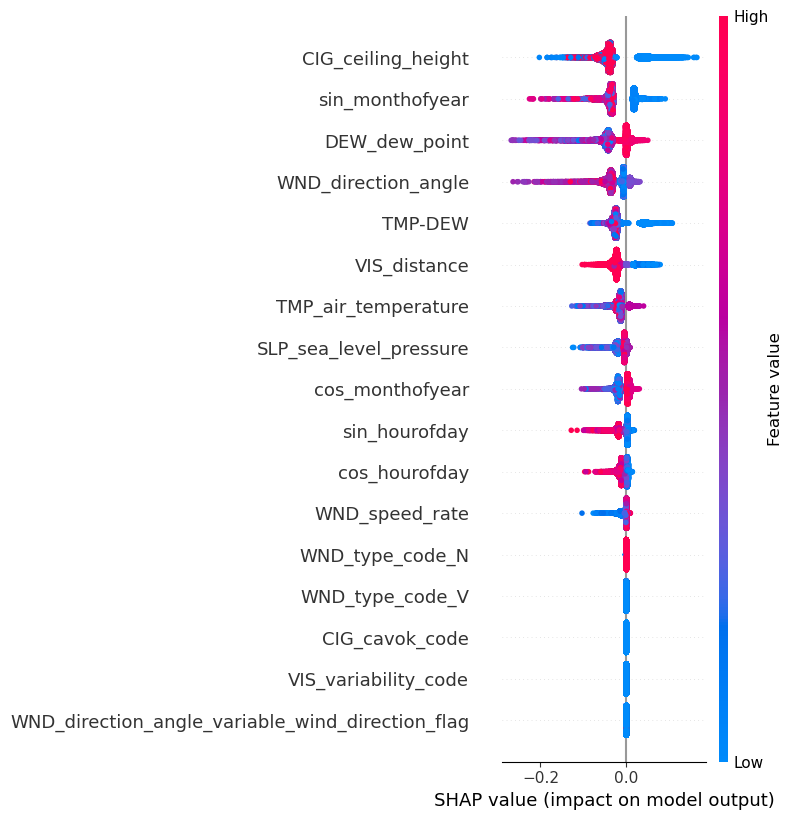

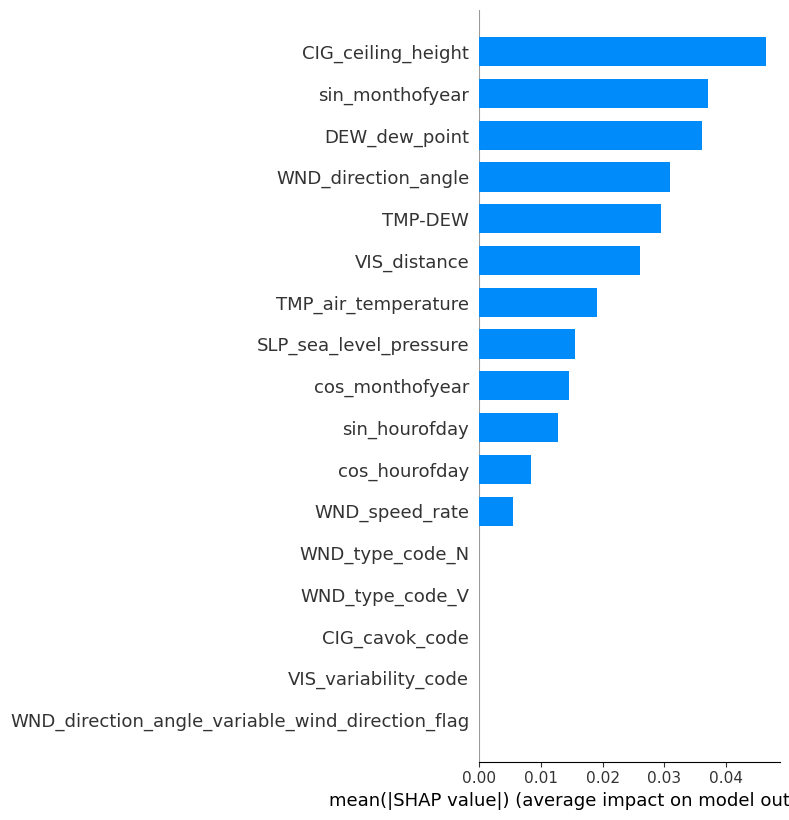

In [11]:
best_model_name = 'TC_DT_RF_SMOTE'
calibrated_model = fe_rfsmote_models[best_model_name]
calibrated_model.fit(X_train, y_train)
base_estimator = calibrated_model.calibrated_classifiers_[0].estimator
preprocessing_pipeline = base_estimator[:-2]  # Everything except SMOTE and classifier
rf_classifier = base_estimator.named_steps['classifier']

# Transform validation data through preprocessing only (no SMOTE)
X_val_preprocessed = preprocessing_pipeline.transform(X_val)

# Use the fitted pipeline to get the feature names
feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_val_preprocessed)





shap_values_to_plot=shap_values[:, :, 1]
# Plot
shap.summary_plot(
    shap_values_to_plot, 
    X_val_preprocessed, 
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
save_to = project_root/'results/modeling_and_feature_eng_figures/shaps/shap_summary_RF_DT_TC_HR.png'
plt.savefig(save_to)
plt.show()

# Bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_val_preprocessed,feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
save_to = project_root/'results/modeling_and_feature_eng_figures/shaps/shap_importance_RF_DT_TC_HR.png'
plt.savefig(save_to, dpi=300, bbox_inches='tight')
plt.show()







**Analysis:**
Based on our SHAP Figures for `TC_DT_RF_SMOTE`, our engineered features are contributing to the model's predictions on our validation data. In particular `TMP-DEW` ranks high among the features.

The following have near in our models predictions for our validation data, so we will drop them and see how our model performs:

* `WND_type_code_V`,
* `CIG_cavok_code`,
* `VIS_variability_code`,
* `WND_type_code_n`,
* `WND_direction_angle_variable_wind_direction_flag`


## 8. FE + Feature Drops 

For our selected model `TC_DT_RF_SMOTE` , we will compare their baseline  performance to what happens when we drop: 

* `WND_type_code_V`,
* `CIG_cavok_code`,
* `VIS_variability_code`,
* `WND_type_code_n`,
* `WND_direction_angle_variable_wind_direction_flag`



The following code creates the preprocessors that drop 

* `WND_type_code_V`,
* `CIG_cavok_code`,
* `VIS_variability_code`,
* `WND_type_code_N`,
* `WND_direction_angle_variable_wind_direction_flag`

In [12]:
#=========================================================================
# PREPROCESSING COLUMN TRANSFORMER ADDITIONAL CIG DROP
#=========================================================================

#TC= time-conversion
#DT= dew temp spread
#HR = hourly rates
#OG = original


additional_drops = ['CIG_cavok_code',
                    'VIS_variability_code',
                    'WND_type_code',  
                    'WND_direction_angle_variable_wind_direction_flag'
                    ]




DROP_TC_DT_preprocessor = ColumnTransformer(
    transformers=[
        ('feat_engin_temp_dew',feat_engin_numeric_pipeline,feat_engin_temp_dew),
        #('feat_engin_rolling_average',feat_engin_numeric_pipeline,feat_engin_rolling_average),
        ('feat_engin_time_features', feat_engin_numeric_pipeline, feat_engin_time_features),
        ('numeric_feature_pipeline', numeric_pipeline, numeric_features),
        #('binary_pipeline', turn_to_binary_pipeline, keep_binary_features), gets rid of CIG_cavok_code and VIS_variability_code
        #('nominal_pipeline', nominal_features_pipeline, nominal_features), gets rid of wnd type code
        #('passthrough_features','passthrough', binary_features),  get rid of `WND_direction_angle_variable_wind_direction_flag`
        ('drop_features','drop', datetime_features),
        ('additional_drops','drop', additional_drops)
    ],
    verbose_feature_names_out=False
)




In [13]:
models = {}









models['TC_DT_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    
    ('preprocessor', TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])










models['DROP_TC_DT_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', DROP_TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])



    
for name,model in models.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                    
    )

    models[name]=calibrated_model

In [21]:

# fit models
models_object = mds.ModelingUtilities(dict_of_models=models)
models_object.fit_models(X_train,y_train)
models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
models_object.get_train_best_fbeta_thresholds(y_train,beta=2)


# Step 3: Now evaluate on test with locked threshold
models_object.save_test_probabilities(X_val, testing_type='validation')
models_metrics = models_object.get_metrics(
    y_data=y_val,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


# save
save_to = project_root/pathlib.Path('results/modeling_and_feature_eng_metrics/TC_DT_plus_DROP_models.csv')
models_metrics.to_csv(save_to)

print('='*80)

print('METRICS')
display(models_metrics)

Fitting model DROP_DT_TC_RF_SMOTE
METRICS


,Model,Parameters,validation_Threshold,validation_avg_precision,validation_F2,validation_Recall,validation_Precision,validation_roc_auc,validation_brier_score
0,DROP_DT_TC_RF_SMOTE,{'cv': YearlyTemporalWindowSplit(end_year=2017...,0.041303,0.071004,0.082372,0.08547,0.071942,0.898138,0.002131


### 8.1 Metric Summary
The metrics above show that dropping `CIG_cavok_code`, `VIS_variability_code`,`WND_type_code`,  `WND_direction_angle_variable_wind_direction_flag` improved the AP of `TC_HR_RF_ROS` slightly while dropping its F2 score. On the other hand, dropping negatively affect average precision score for `TC_HR_XGBoost_SMOTE` by about a percent, while only dropping its F2 score slightly. 


Before deciding if dropping is too harmful, we look at how much overfitting is going on in all of these models.


In [15]:

data_dict = {'train': {'X':X_train,'y':y_train},
            'validation':{'X':X_val,'y':y_val}}
save_to=project_root/'results/modeling_and_feature_eng_metrics/tc_dt_rf_smote_with_drops.csv'

tc_dt_rf_smote_with_drops_df = mds.train_val_model_metrics_df(models_dict=models,data_dict=data_dict)
tc_dt_rf_smote_with_drops_df['train_val_ap_ratio'] = tc_dt_rf_smote_with_drops_df['train_avg_precision']/tc_dt_rf_smote_with_drops_df['validation_avg_precision']
tc_dt_rf_smote_with_drops_df.to_csv(save_to)
display(tc_dt_rf_smote_with_drops_df)


Fitting model TC_DT_RF_SMOTE
Fitting model DROP_TC_DT_RF_SMOTE


,Model,train_avg_precision,validation_avg_precision,train_F2,validation_F2,train_Recall,validation_Recall,train_Precision,validation_Precision,train_roc_auc,validation_roc_auc,train_brier_score,validation_brier_score,Parameters,train_val_ap_ratio
0,TC_DT_RF_SMOTE,0.352021,0.064942,0.430782,0.089141,0.546419,0.094017,0.233296,0.073826,0.987276,0.914068,0.001290,0.002130,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.420536
1,DROP_TC_DT_RF_SMOTE,0.347469,0.071004,0.446447,0.082372,0.571618,0.085470,0.237990,0.071942,0.988056,0.898138,0.001315,0.002131,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.893655


### 8.2 Train-Validation Performance

Based on the metrics above, dropping these additional columns looks to improve the train to validation AP score ratio, from 5.418740 to 4.893455.  We thus choose to continue with the `DROP_TC_DT_RF_SMOTE` model. In addition the ap score of `DROP_TC_DT_RF_SMOTE` is higher.



In [16]:
models = {}

models['DROP_DT_TC_RF_SMOTE'] = ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', DROP_TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])


for name,model in models.items():
    calibrated_model = CalibratedClassifierCV(
    estimator=model,  
    method='isotonic',        
    cv=expanding_cv                      
    )

    models[name]=calibrated_model
    
    
    


In [17]:
# Save this model

import joblib
import json
from datetime import datetime
import pathlib
DROP_DT_TC_RF_SMOTE = models['DROP_DT_TC_RF_SMOTE']
# Train model

DROP_DT_TC_RF_SMOTE.fit(X_train, y_train) # now trained on train+val data

# ============================================================
# 1. Save the trained pipeline
# ============================================================
model_dir = project_root / pathlib.Path('models')
model_dir.mkdir(exist_ok=True)

model_path = model_dir / 'DROP_DT_TC_RF_SMOTE.joblib'
joblib.dump(DROP_DT_TC_RF_SMOTE, model_path)
print(f"Model saved to {model_path}")


Model saved to /Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/models/DROP_DT_TC_RF_SMOTE.joblib


### 8.3 Confusion Matrices

Fitting model DROP_DT_TC_RF_SMOTE


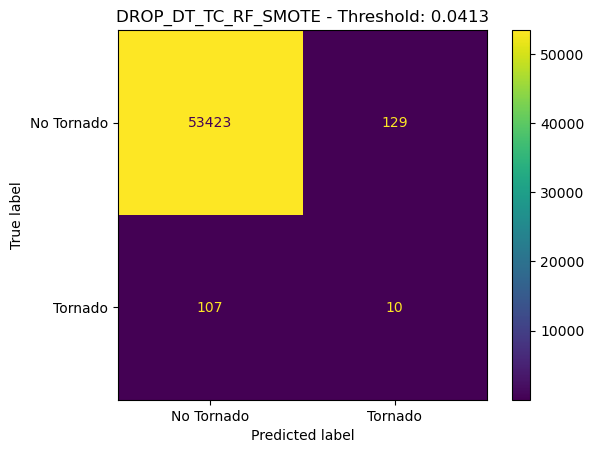

In [18]:
# fit models
models_object = mds.ModelingUtilities(dict_of_models=models)
models_object.fit_models(X_train,y_train)
models_object.save_training_probabilities(X_train)

# save/get training best f2 threshold
models_object.get_train_best_fbeta_thresholds(y_train,beta=2)



# Step 3: Now evaluate on test with locked threshold
models_object.save_test_probabilities(X_val, testing_type='validation')


save_to_dir=project_root/pathlib.Path('results/modeling_and_feature_eng_figures/confusion_matrix')
models_object.create_confusion_matrix(y_val=y_val,use_train_threshold=True, save_to_dir=save_to_dir)


### 8.4 PR Curves

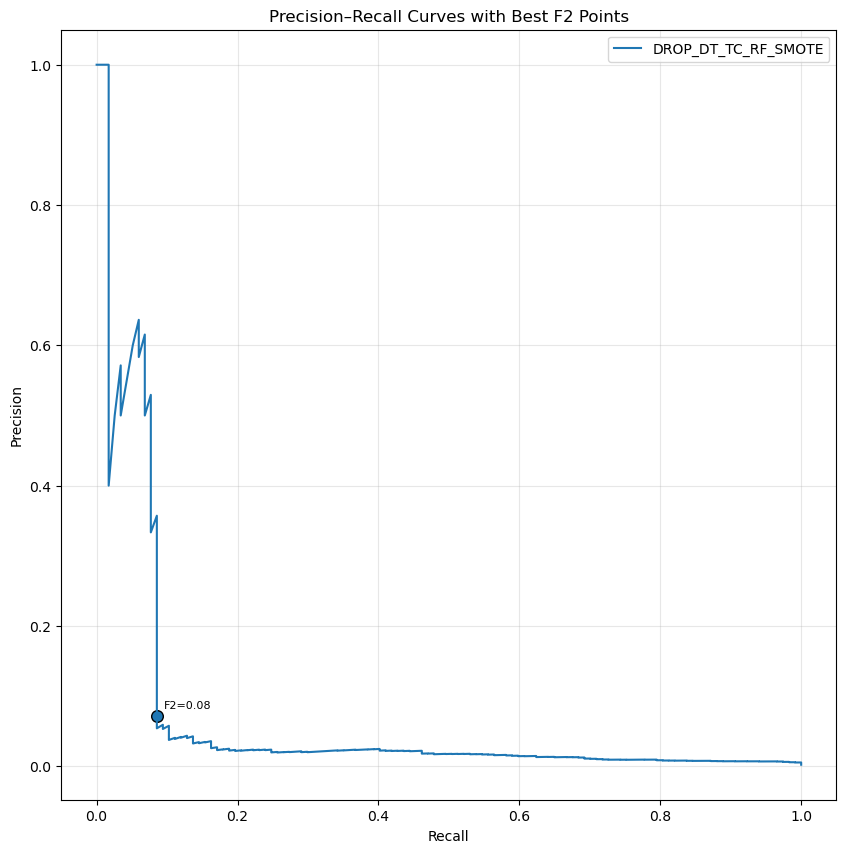

In [19]:
save_to=project_root/pathlib.Path('results/modeling_and_feature_eng_figures/prec_rec_curves/final_rf.png')
models_object.plt_precision_recall_curve(y_val=y_val,beta=2,use_train_threshold=True, save_to=save_to)

### 8.5 Error Analysis


Validation Set Error Analysis (threshold=0.04130332464626574):
True Positives: 10
False Positives: 129
True Negatives: 53423
False Negatives: 107


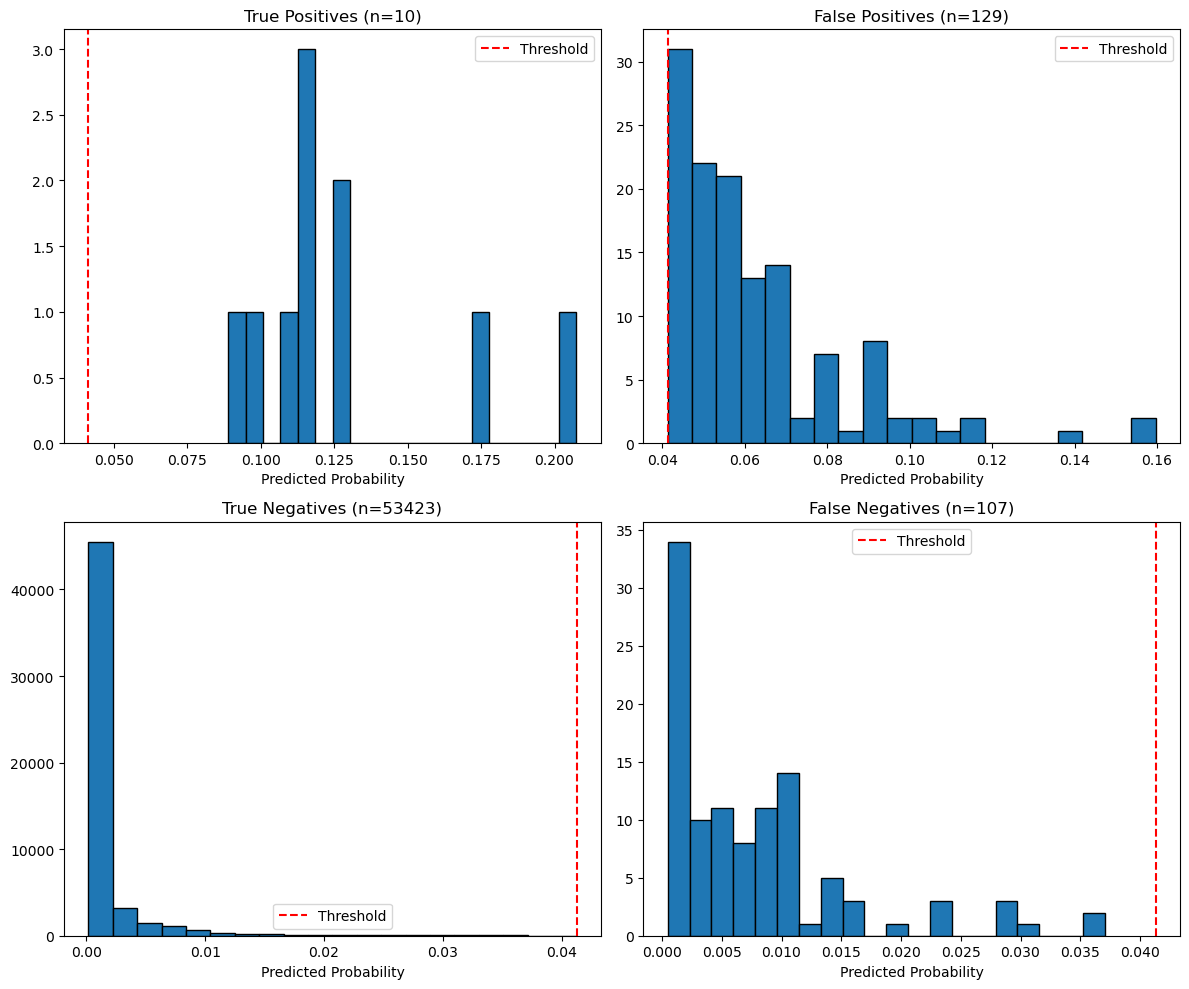


--- Feature Analysis for Errors ---

False Positives (False Alarms) - Top feature values:
STATION                   7.235382e+10
VIS_distance              1.376798e+04
SLP_sea_level_pressure    1.007550e+04
CIG_ceiling_height        1.307605e+03
ELEVATION                 3.934163e+02
TMP_air_temperature       2.139612e+02
DEW_dew_point             1.836512e+02
WND_direction_angle       1.631783e+02
WND_speed_rate            7.332558e+01
LATITUDE                  3.543764e+01
dtype: float64

False Negatives (Missed Tornadoes) - Top feature values:
STATION                   7.235382e+10
VIS_distance              1.547637e+04
SLP_sea_level_pressure    1.008724e+04
CIG_ceiling_height        6.902140e+03
ELEVATION                 3.934327e+02
TMP_air_temperature       2.414579e+02
DEW_dew_point             1.906355e+02
WND_direction_angle       1.654717e+02
WND_speed_rate            5.444860e+01
LATITUDE                  3.543911e+01
dtype: float64

True Positives (Caught Tornadoes) - Top 

In [20]:
y_pred_proba=models_object.test_probabilities ['DROP_DT_TC_RF_SMOTE']
threshold = models_object.train_best_thresholds['DROP_DT_TC_RF_SMOTE']

au.error_analysis(X_val,y_val,y_pred_proba,threshold=threshold, dataset_name='Validation')

**Findings**

1) Most of our false positive are very close to the threshold.
2) Most of our false negative are being assigned a probability of around  0.005 by our model.
3) Most of our true negatives are near 0-0.01%.


These items suggest that our model is certainly picking up on tornado indicators but is misclassifying quite a few of them (the cluster near 0.005%). From the top feature values above we see that our false negatives have a high air temperature and (relatively) high dew point in comparison to the False Positives and True Positives. Based on our SHAP values our model has learned and is putting more weight into seasonal information through sin_monthofyear and cos_monthofyear. The model with TC features might be achieving good overall performance by heavily weighting seasonal probability, but missing individual tornado events that don't fit seasonal norms. However, when we drop the TC feature, we saw above that our models AP score tanks and does not go above a .03 AP. 

This represents a fundamental challenge in operational tornado prediction: balancing the strong seasonal signal that improves overall performance against the need to identify rare, out-of-season tornado events. One possibility is to create an ensemble with `DROP_HR_RF_SMOTE`; because of time restriction, we don't do this here. In addition,  **it is likely that including radar features will help with this**. 

## 8. Next Step

With feature engineering and feature selection out of the way, we now move to final model selection and testing in the [final_results](final_results.ipynb) notebook.